# Dengue Platelet Guardian - Advanced ML Pipeline

This notebook covers the complete lifecycle of the Dengue prediction model:
- A. Data Collection
- B. Data Preprocessing
- C. Exploratory Data Analysis (EDA)
- D. Data Cleaning and Removing Outliers
- E. Algorithms & Model Training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error
import joblib
import os

%matplotlib inline
sns.set(style="whitegrid")

## A. Data Collection

In [2]:
# Load the dataset
data_path = 'Dengue-Dataset.csv'
df = pd.read_csv(data_path)
print(f"Data collection complete. Shape: {df.shape}")
df.head()

Data collection complete. Shape: (1523, 19)


,Gender,Age,Hemoglobin(g/dl),Neutrophils(%),Lymphocytes(%),Monocytes(%),Eosinophils(%),RBC,HCT(%),MCV(fl),MCH(pg),MCHC(g/dl),RDW-CV(%),Total Platelet Count(/cumm),MPV(fl),PDW(%),PCT(%),Total WBC count(/cumm),Result
0,Male,21,14.8,48,47,3,2,5,48.00,96.0,29.60,30.8,11.6,112000,10.70,15.40,0.120,5100,positive
1,Male,30,15.0,47,49,6,3,5,49.80,96.1,28.40,29.5,11.8,96000,10.60,15.80,0.121,4500,positive
2,Male,51,16.3,41,48,4,5,5,50.10,93.5,31.30,32.7,13.5,184000,10.40,16.40,0.130,6000,negative
3,Female,26,12.3,46,49,7,5,5,44.00,90.0,30.50,30.5,14.7,167000,8.10,17.10,0.110,5000,negative
4,Male,35,16.1,45,46,4,4,5,50.53,91.0,29.12,29.2,15.2,155000,10.52,12.34,0.150,4600,negative


## B. Exploratory Data Analysis (EDA)

C:\Users\jahna\AppData\Local\Temp\ipykernel_8400\3772208898.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Result', data=df, palette='viridis')


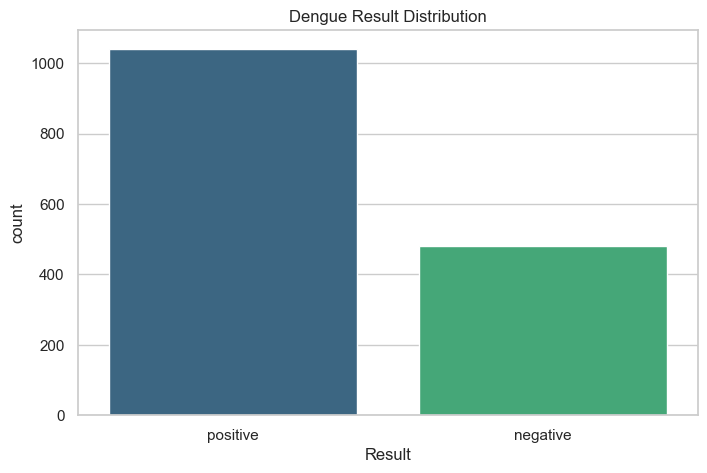

In [3]:
# 1. Distribution of the target variable (Result)
plt.figure(figsize=(8, 5))
sns.countplot(x='Result', data=df, palette='viridis')
plt.title('Dengue Result Distribution')
plt.show()

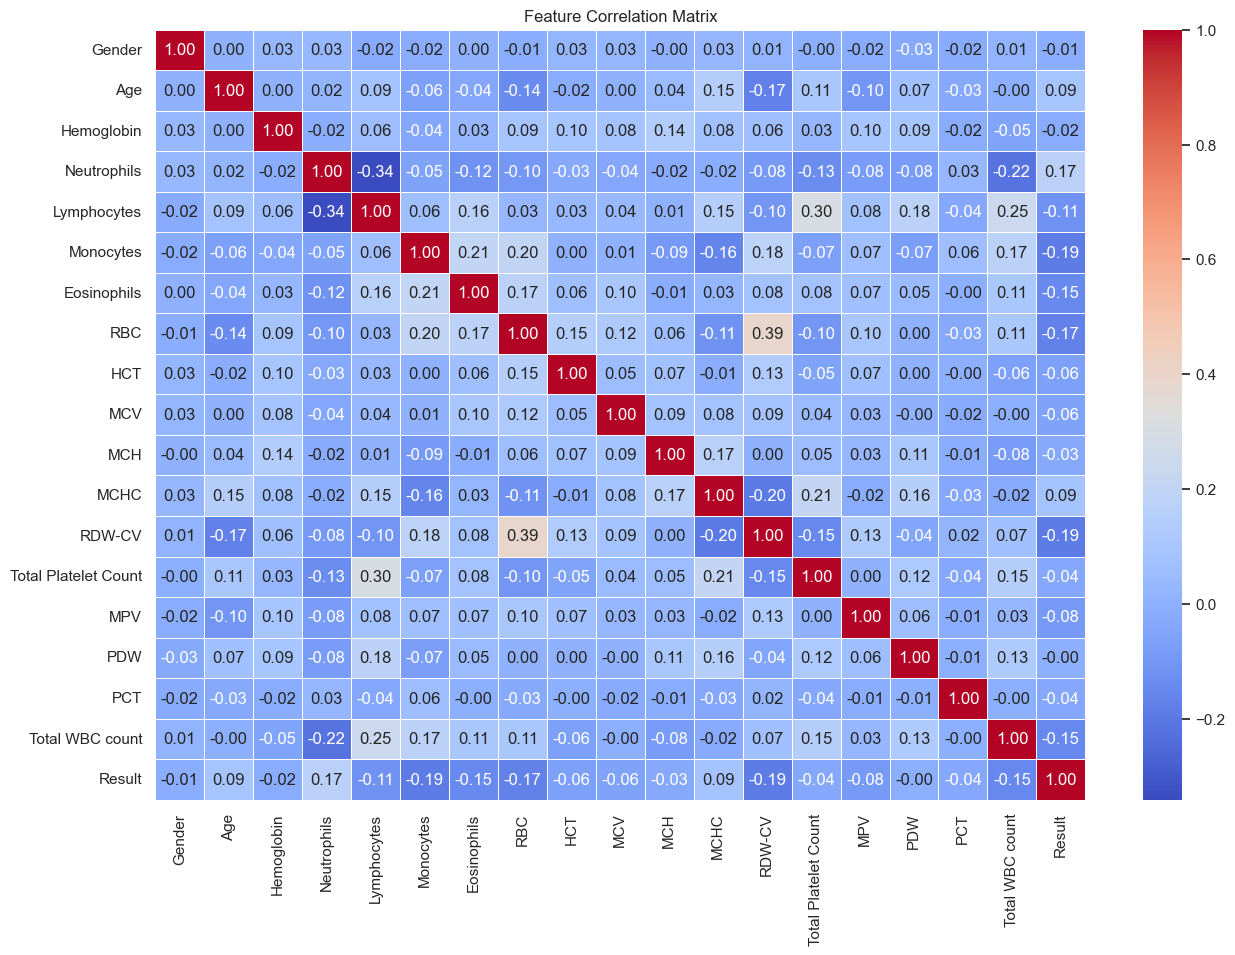

In [4]:
# Clean column names for easier plotting
df_clean = df.copy()
df_clean.columns = [c.split('(')[0].strip() for c in df_clean.columns]

# 2. Correlation Matrix
plt.figure(figsize=(15, 10))
# Encode categorical for correlation
df_corr = df_clean.copy()
df_corr['Gender'] = LabelEncoder().fit_transform(df_corr['Gender'])
df_corr['Result'] = LabelEncoder().fit_transform(df_corr['Result'])

corr = df_corr.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

## C. Data Preprocessing & Cleaning

In [5]:
# 1. Handling Missing Values & Column Cleaning
# Clean column names (remove units like (g/dl))
df_clean.columns = [c.split('(')[0].strip() for c in df_clean.columns]

numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
imputer = SimpleImputer(strategy='median')
df_clean[numeric_features] = imputer.fit_transform(df_clean[numeric_features])

# 2. Encoding Gender & Result
le_result = LabelEncoder()
df_clean['Gender'] = LabelEncoder().fit_transform(df_clean['Gender'].astype(str))
df_clean['Result'] = le_result.fit_transform(df_clean['Result'].astype(str).str.lower())

print("Preprocessing complete. Features synced with API.")

Preprocessing complete.


## D. Data Cleaning and Removing Outliers

In [6]:
# Removing outliers using the IQR method
Q1 = df_clean[numeric_features].quantile(0.25)
Q3 = df_clean[numeric_features].quantile(0.75)
IQR = Q3 - Q1

# Filter out outliers
df_final = df_clean[~((df_clean[numeric_features] < (Q1 - 1.5 * IQR)) | (df_clean[numeric_features] > (Q3 + 1.5 * IQR))).any(axis=1)]
print(f"Original rows: {len(df_clean)}, Rows after outlier removal: {len(df_final)}")

Original rows: 1523, Rows after outlier removal: 1331


## E. Algorithms & Training

In [7]:
# Feature Scaling
features_to_scale = ['Age', 'Hemoglobin', 'RBC', 'HCT', 'MCV', 'MCH', 'MCHC', 
                     'RDW-CV', 'Total Platelet Count', 'MPV', 'PDW', 'PCT', 'Total WBC count']
scale_cols = [col for col in features_to_scale if col in df_final.columns]

scaler = StandardScaler()
df_final[scale_cols] = scaler.fit_transform(df_final[scale_cols])

# Train Test Split
X = df_final.drop(['Result'], axis=1)
y = df_final['Result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset split completed. X shape: {X.shape}")

Logistic Regression Accuracy: 0.7790


Random Forest Accuracy: 0.7640
XGBoost Accuracy: 0.7303


In [ ]:
# Step 3: ML Model Processing

# 3.1 Logistic Regression (Baseline)
print("\n--- Logistic Regression ---")
lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

# 3.2 Random Forest Classifier
print("\n--- Random Forest Classifier ---")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

# 3.3 XGBoost Classifier
print("\n--- XGBoost Classifier ---")
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")

# 3.4 XGBoost Regressor for Platelet Decline Forecast
X_reg = df_final.drop(['Total Platelet Count', 'Result'], axis=1)
y_reg = df_final['Total Platelet Count']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
reg_model.fit(X_train_reg, y_train_reg)
y_pred_reg = reg_model.predict(X_test_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
print(f"Platelet Forecast MAE (Scaled): {mae:.4f}")

In [ ]:
# Save Results and Visualization
# Create results folder
results_dir = 'results'
os.makedirs(results_dir, exist_ok=True)

# Generate Accuracy Report
report_path = os.path.join(results_dir, 'accuracy_report.txt')
with open(report_path, 'w') as f:
    f.write("Dengue Platelet Guardian - Accuracy Report (Notebook Run)\n")
    f.write("==========================================\n\n")
    f.write(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
    f.write(f"XGBoost Classifier Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}\n")
    f.write(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n\n")
    
    f.write("--- Random Forest Classification Report ---\n")
    f.write(classification_report(y_test, y_pred_rf))
    
    f.write("\n--- XGBoost Classification Report ---\n")
    f.write(classification_report(y_test, y_pred_xgb))
    
    f.write("\n--- Logistic Regression Classification Report ---\n")
    f.write(classification_report(y_test, y_pred_lr))
    
    f.write(f"\nPlatelet Forecast MAE (Scaled): {mae:.4f}\n")

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_result.classes_, yticklabels=le_result.classes_)
plt.title('Dengue Prediction Confusion Matrix (Random Forest)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig(os.path.join(results_dir, 'confusion_matrix.png'))
plt.show()

# Feature Importance
plt.figure(figsize=(10, 8))
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Features Impacting Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'feature_importance.png'))
plt.show()

print(f"Results and plots saved in: {results_dir}")